# Characterization and Changing Nature of Aerosol Extreme Events over the U.S. Southwest

This code reproduces Figure 5 from the paper

By: Juliana Mejia Sepulveda
email: julianamejia@arizona.edu

In [48]:
import pandas as pd
import xarray as xr
import numpy as np
from scipy import interpolate
from scipy.stats import pearsonr, spearmanr
from scipy.stats import linregress

import os
from multiprocessing import Pool

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from matplotlib import cm
from matplotlib import colors
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

## 1. SPEI data

In [4]:
spei_data = pd.read_csv('/home/u32/julianamejia/data/merra_data/SPEI_32.25_-110.75.csv', index_col = 'DATA')

## 2. AERONET

In [42]:
file_path = '/home/u32/julianamejia/data/aeronet_data/aeronet_Tucson.lev20.xlsx'
aod_data = pd.read_excel(file_path, usecols=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)', 'AOD_500nm'])

In [43]:
# 1. Convert 'Date(dd:mm:yyyy)' to datetime format (%d:%m:%Y)
aod_data['Date(dd:mm:yyyy)'] = pd.to_datetime(aod_data['Date(dd:mm:yyyy)'], format='%d:%m:%Y', errors='coerce')
null_date = aod_data['Date(dd:mm:yyyy)'].isnull().sum()
    
# 2. Combine date and time into a single DateTime string
aod_data['DateTime'] = aod_data['Date(dd:mm:yyyy)'].astype(str) + ' ' + aod_data['Time(hh:mm:ss)'].astype(str)
    
# 3. Convert the combined string to proper datetime object
aod_data['DateTime'] = pd.to_datetime(aod_data['DateTime'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
null_datetime = aod_data['DateTime'].isnull().sum()
    
# 4. Drop original date and time columns
aod_data = aod_data.drop(columns=['Date(dd:mm:yyyy)', 'Time(hh:mm:ss)'])

In [44]:
# 1. Replace -999 with NaN
aod_data.replace(-999, np.nan, inplace=True)

# 2. Set DateTime as index
aod_data = aod_data.set_index('DateTime')

# 3. Select only the AOD_550nm column
aod = aod_data[['AOD_500nm']]

# 4. Resample to daily max
daily_max = aod.resample('1D', closed='right').max()
daily_mean = aod.resample('1D', closed='right').mean()

# 5. Resample to monthly mean based on the daily max
monthly_mean = daily_max.resample('1M', closed='right').mean()

## 3. MERRA-2 and CAMS

In [9]:
#====Directory====
dir_aod = '/xdisk/sylvia/julianamejia/cams_aod'

In [14]:
#====Reading files====
ds_aod_sw = []
file_names = []
errors = []


for archivo in os.listdir(dir_aod):
    if archivo.endswith('.nc'):
        file_path = os.path.join(dir_aod, archivo)
        try:
            ds_aod = xr.open_dataset(file_path, engine="netcdf4")
            ds_aod_sw.append(ds_aod)
            file_names.append(archivo)
        except FileNotFoundError:
            errors.append(archivo)

In [15]:
#====Concat files by time====
aod_cams = xr.concat(ds_aod_sw, dim='valid_time', coords='minimal')
aod_cams = aod_cams.sortby('valid_time')

In [16]:
# === Convert UTC time to Arizona local time ===
# Step 1: Get the existing UTC time values from 'time' coordinate
time_utc = pd.DatetimeIndex(aod_cams['valid_time'].values)

# Step 2: Convert from UTC to Arizona time
time_arizona = time_utc.tz_localize('UTC').tz_convert('America/Phoenix')

# Step 3: Replace the 'time' coordinate with Arizona-local time (correct dtype)
aod_cams = aod_cams.assign_coords(time=time_arizona)

aod_cams['time'] = pd.to_datetime(aod_cams['valid_time'].values)

aod_cams = aod_cams.drop_vars('valid_time')

In [17]:
aod_cams = aod_cams.rename({'valid_time': 'time'})

In [45]:
#====Resample AOD to daily maximum====
daily_max_aod = aod_cams[['aod550','bcaod550','duaod550']].groupby(aod_cams['time'].dt.floor('D')).max('time')

# Rename the new dimension to time
daily_max_aod = daily_max_aod.rename({'floor': 'time'})

# Assign result to another variable
max_aod_cams = daily_max_aod

#====Resample AOD to daily mean====
daily_mean_aod = aod_cams[['aod550','bcaod550','duaod550']].groupby(aod_cams['time'].dt.floor('D')).mean('time')

# Rename the new dimension to time
daily_mean_aod = daily_mean_aod.rename({'floor': 'time'})

# Assign result to another variable
mean_aod_cams = daily_mean_aod

In [19]:
#====Directory====
dirme_aod = '/xdisk/sylvia/julianamejia/tmp_merra_aod'

In [20]:
#====Reading files====
ds_aod_merra = []
file_names = []
errors = []


for archivo in os.listdir(dirme_aod):
    if archivo.endswith('.nc4'):
        file_path = os.path.join(dirme_aod, archivo)
        try:
            dsme_aod = xr.open_dataset(file_path, engine="netcdf4")
            ds_aod_merra.append(dsme_aod)
            file_names.append(archivo)
        except FileNotFoundError:
            errors.append(archivo)

In [21]:
#====Concat files by time====
aod_merra = xr.concat(ds_aod_merra, dim='time', coords='minimal')
aod_merra = aod_merra.set_index(time='time')
aod_merra = aod_merra.sortby('time')

In [46]:
#====Resample AOD to daily maximum====
daily_max_aod_merra = aod_merra[['TOTEXTTAU', 'BCEXTTAU', 'DUEXTTAU','OCEXTTAU']].groupby(aod_merra['time'].dt.floor('D')).max('time')

# Rename the new dimension to time
daily_max_aod_merra = daily_max_aod_merra.rename({'floor': 'time'})

# Assign result to another variable
max_aod_merra = daily_max_aod_merra

#====Resample AOD to daily mean====
daily_mean_aod_merra = aod_merra[['TOTEXTTAU', 'BCEXTTAU', 'DUEXTTAU','OCEXTTAU']].groupby(aod_merra['time'].dt.floor('D')).mean('time')

# Rename the new dimension to time
daily_mean_aod_merra = daily_mean_aod_merra.rename({'floor': 'time'})

# Assign result to another variable
mean_aod_merra = daily_mean_aod_merra

In [24]:
lat0, lon0 = 32.25, -110.75

# Nearest Grid to SPEI and Tucson Site Coordinates
cams_point  = max_aod_cams.sel(latitude=lat0, longitude=lon0, method="nearest")
merra_point = max_aod_merra.sel(lat=lat0, lon=lon0, method="nearest")

def da_to_monthly_period(da):
    """DataArray with time -> monthly PeriodIndex series (monthly mean)."""
    s = da.to_series()  # DatetimeIndex
    s = s.groupby(s.index.to_period("M")).mean()
    return s

# --- CAMS monthly (from daily-max dataset) ---
cams_AOD  = da_to_monthly_period(cams_point["aod550"]).rename("CAMS_AOD")
cams_DUST = da_to_monthly_period(cams_point["duaod550"]).rename("CAMS_DUST")
cams_BC   = da_to_monthly_period(cams_point["bcaod550"]).rename("CAMS_BC")

# --- MERRA monthly (from daily-max dataset) ---
merra_TOT  = da_to_monthly_period(merra_point["TOTEXTTAU"]).rename("MERRA_TOT")
merra_DUST = da_to_monthly_period(merra_point["DUEXTTAU"]).rename("MERRA_DUST")
merra_BC   = da_to_monthly_period(merra_point["BCEXTTAU"]).rename("MERRA_BC")

In [25]:
# from AERONET monthly_mean
aeronet = monthly_mean["AOD_500nm"].copy()
aeronet.index = pd.to_datetime(aeronet.index)
aeronet = aeronet.groupby(aeronet.index.to_period("M")).mean()
aeronet = aeronet.rename("AERONET_AOD")

# SPEI (your fixed method)
# SPEI index is already datetime-like (e.g., 1950-01-01)
spei_idx = pd.to_datetime(spei_data.index)          
spei = pd.Series(
    pd.to_numeric(spei_data["SPEI_1"], errors="coerce").to_numpy(),
    index=spei_idx.to_period("M"),
    name="SPEI_1"
)


/tmp/ipykernel_3377266/3213318426.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  spei_idx = pd.to_datetime(spei_data.index)


In [27]:
full_months = pd.period_range("2000-01", "2024-12", freq="M")
df = pd.DataFrame(index=full_months)

df["SPEI_1"]      = spei
df["CAMS_DUST"]   = cams_DUST
df["MERRA_DUST"]  = merra_DUST
df["CAMS_BC"]     = cams_BC
df["MERRA_BC"]    = merra_BC
df["AERONET_AOD"] = aeronet
df['MERRA_TOT']   = merra_TOT
df['CAMS_AOD']    = cams_AOD

In [28]:
df_plot = df.copy()
df_plot.index = df_plot.index.to_timestamp(how="start")

In [31]:
overlap = pd.concat(
    [spei, aeronet, cams_AOD, cams_DUST, cams_BC, merra_TOT, merra_DUST, merra_BC],
    axis=1
)
# keep only the time window we want to plot
overlap = overlap.loc["2015-01":"2024-12"]

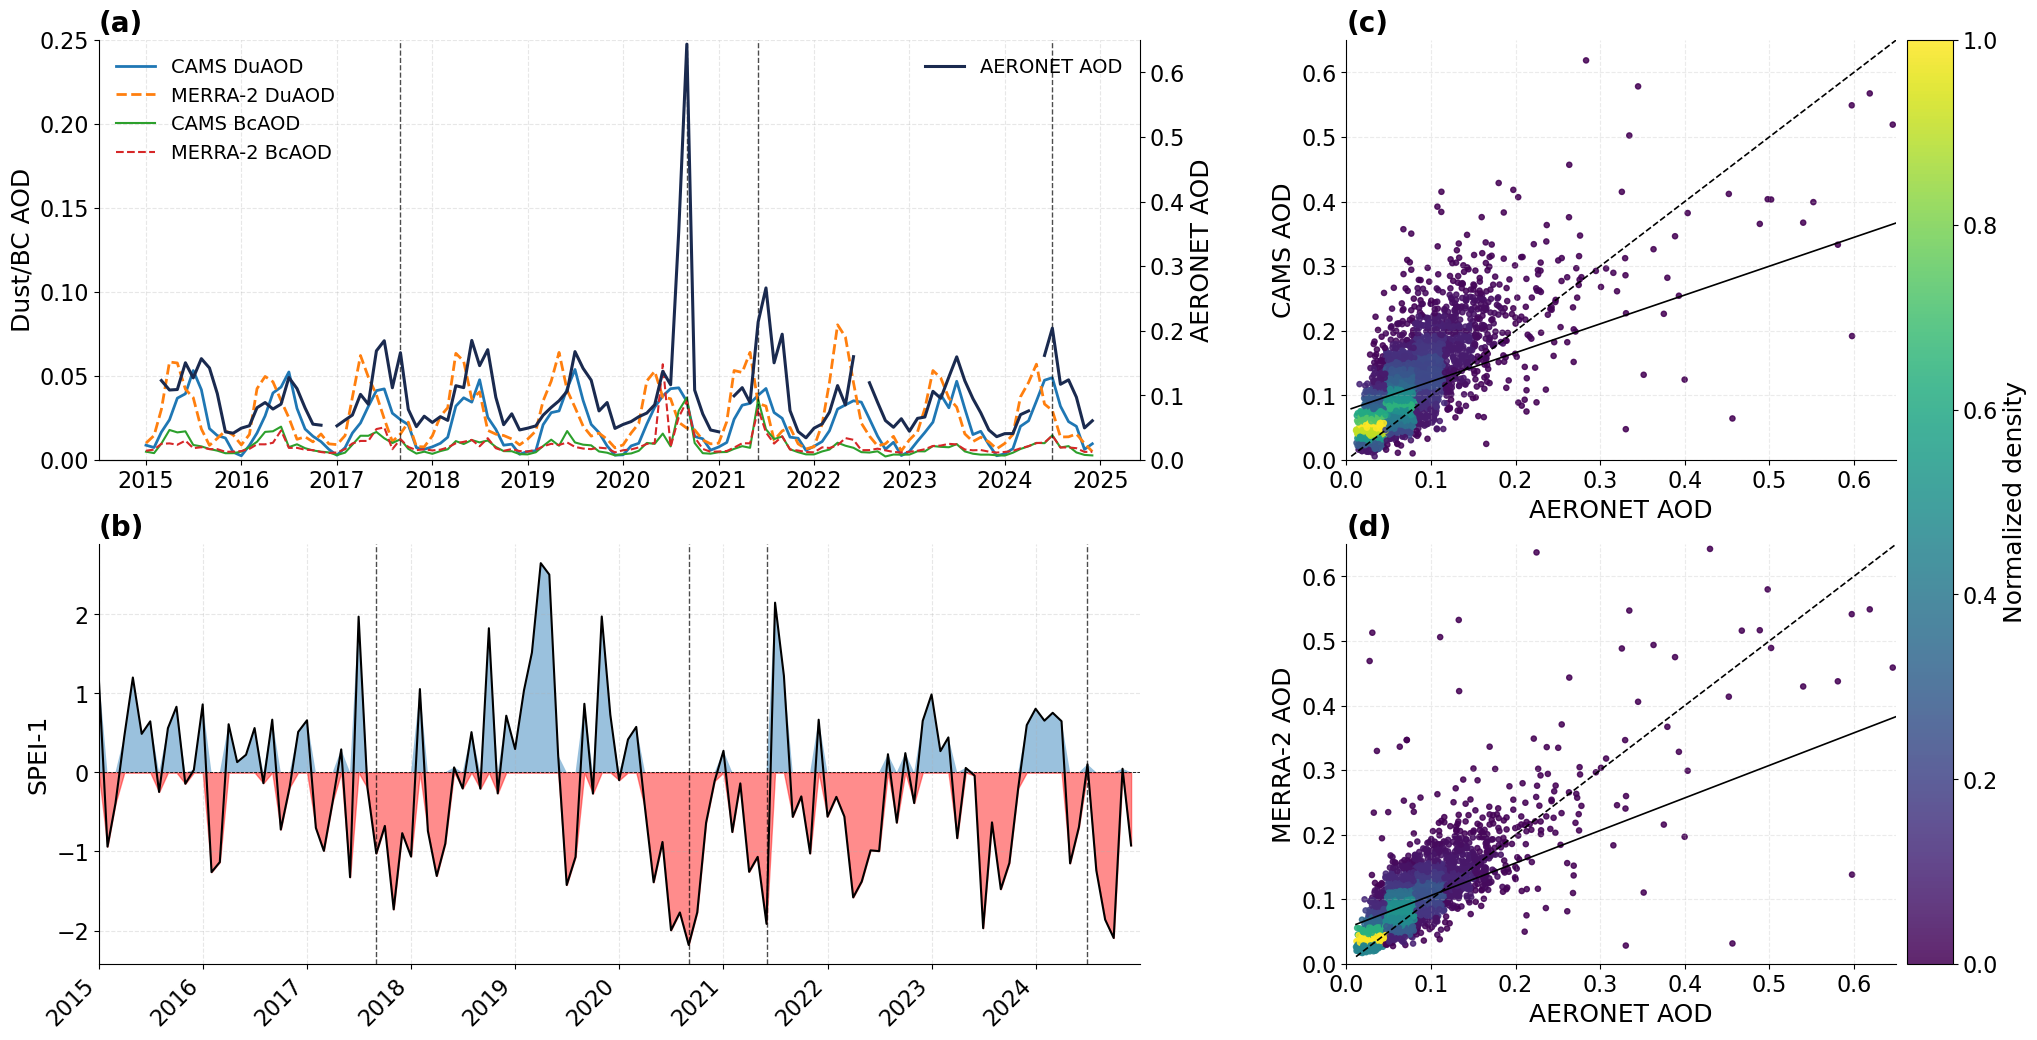

In [69]:
plt.close('all')

# ==================================================
# 1) Prepare data
# ==================================================
ov_b = overlap.copy()
ov_b = ov_b.dropna(subset=["CAMS_DUST", "AERONET_AOD"])
ov_b.index = ov_b.index.to_timestamp(how="start")

lat0, lon0 = 32.25, -110.75

aero = daily_mean["AOD_500nm"].copy()
aero.index = pd.to_datetime(aero.index)
aero.name = "AERONET_AOD"

cams = mean_aod_cams.sel(latitude=lat0, longitude=lon0, method="nearest")["aod550"].to_series()
cams.name = "CAMS_AOD"

merra = mean_aod_merra.sel(lat=lat0, lon=lon0, method="nearest")["TOTEXTTAU"].to_series()
merra.name = "MERRA_AOD"

df_cams = pd.concat([aero, cams], axis=1).dropna()
df_merra = pd.concat([aero, merra], axis=1).dropna()

# ---- Subset time series to 2015 onward ----
start_date = pd.Timestamp("2015-01-01")
end_date   = pd.Timestamp("2024-12-31")
df_plot_sub = df_plot.loc[(df_plot.index >= start_date) & (df_plot.index <= end_date)].copy()

# ==================================================
# 2) Helpers
# ==================================================
def density_colors(x, y, bins=70):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x0, y0 = x[mask], y[mask]

    H, xedges, yedges = np.histogram2d(x0, y0, bins=bins)
    xi = np.clip(np.digitize(x0, xedges) - 1, 0, H.shape[0] - 1)
    yi = np.clip(np.digitize(y0, yedges) - 1, 0, H.shape[1] - 1)
    d = H[xi, yi].astype(float)

    d = (d - d.min()) / (d.max() - d.min() + 1e-12)

    out = np.full_like(x, np.nan, dtype=float)
    out[mask] = d
    return out

def add_fit(ax, x, y):
    res = linregress(x, y)
    lo = min(np.nanmin(x), np.nanmin(y))
    hi = max(np.nanmax(x), np.nanmax(y))

    ax.plot([lo, hi], [lo, hi], "k--", lw=1.2)
    ax.plot([lo, hi], res.slope * np.array([lo, hi]) + res.intercept, "k-", lw=1.2)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.grid(ls="--", alpha=0.25)

# ==================================================
# 3) Figure 1a-b
# ==================================================
fig, axes = plt.subplots(
    2, 2, figsize=(24, 12),
    gridspec_kw={
        'width_ratios': [1.7, 1],
        'wspace': 0.25,
        'hspace': 0.2
    }
)

# ==================================================
# (a) AOD time series
# ==================================================
ax = axes[0, 0]
x = df_plot_sub.index

ax.plot(x, df_plot_sub["CAMS_DUST"], lw=2, label="CAMS DuAOD")
ax.plot(x, df_plot_sub["MERRA_DUST"], lw=2, ls="--", label="MERRA-2 DuAOD")
ax.plot(x, df_plot_sub["CAMS_BC"], lw=1.5, label="CAMS BcAOD")
ax.plot(x, df_plot_sub["MERRA_BC"], lw=1.5, ls="--", label="MERRA-2 BcAOD")

ax.set_ylabel("Dust/BC AOD", fontsize=18)
ax.set_title('(a)', loc='left', fontweight='bold', fontsize = 20)
ax.set_ylim(0, 0.25)
ax.grid(ls='--', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Twin axis
ax_r = ax.twinx()
ax_r.plot(x, df_plot_sub["AERONET_AOD"], lw=2.2, color="#1A2A4F", label="AERONET AOD")

ax_r.set_ylabel("AERONET AOD", fontsize=18)
ax_r.set_ylim(0, 0.65)

ax_r.spines['top'].set_visible(False)
ax_r.spines['left'].set_visible(False)

ax.legend(loc="upper left", frameon=False, fontsize = 14)
ax_r.legend(loc="upper right", frameon=False, fontsize =14)

# ==================================================
# (b) SPEI
# ==================================================
ax = axes[1, 0]
x = df_plot_sub.index
y = df_plot_sub["SPEI_1"]

ax.plot(x, y, color='black', lw=1.5)
ax.fill_between(x, 0, y.clip(lower=0), alpha=0.45)
ax.fill_between(x, 0, y.clip(upper=0), alpha=0.45, color='red')
ax.axhline(0, color='k', lw=0.6, ls='--')

ax.set_ylabel('SPEI-1', fontsize=18)
ax.set_title('(b)', loc='left', fontweight='bold', fontsize = 20)
ax.grid(ls='--', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(start_date, end_date)

# ==================================================
# Event lines on left column
# ==================================================
event_dates = pd.to_datetime([
    '2017-09-01',
    '2020-09-01',
    '2021-06-01',
    '2024-07-01'
])

for dt in event_dates:
    axes[0, 0].axvline(dt, ls='--', lw=1, color='k', alpha=0.7)
    axes[1, 0].axvline(dt, ls='--', lw=1, color='k', alpha=0.7)

# ==================================================
# (c) CAMS vs AERONET
# ==================================================
ax = axes[0, 1]

x1 = df_cams["AERONET_AOD"].values
y1 = df_cams["CAMS_AOD"].values
c1 = density_colors(x1, y1, bins=80)

sc = ax.scatter(x1, y1, c=c1, s=14, alpha=0.85)

ax.set_title("(c)", loc="left", fontweight="bold", fontsize = 20)
ax.set_xlabel("AERONET AOD", fontsize = 18)
ax.set_ylabel("CAMS AOD", fontsize = 18)

add_fit(ax, x1, y1)

ax.set_xlim(0, 0.65)
ax.set_ylim(0, 0.65)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ==================================================
# (d) MERRA vs AERONET
# ==================================================
ax = axes[1, 1]

x2 = df_merra["AERONET_AOD"].values
y2 = df_merra["MERRA_AOD"].values
c2 = density_colors(x2, y2, bins=80)

sc2 = ax.scatter(x2, y2, c=c2, s=14, alpha=0.85)

ax.set_title("(d)", loc="left", fontweight="bold", fontsize = 20)
ax.set_xlabel("AERONET AOD", fontsize = 18)
ax.set_ylabel("MERRA-2 AOD", fontsize = 18)

add_fit(ax, x2, y2)

ax.set_xlim(0, 0.65)
ax.set_ylim(0, 0.65)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ==================================================
# Shared colorbar for right column
# ==================================================
cbar = fig.colorbar(sc, ax=axes[:, 1], fraction=0.085, pad=0.017)
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Normalized density", fontsize = 18)

# ==================================================
# Tick formatting
# ==================================================
for ax in axes.flatten():
    ax.tick_params(labelsize=16)

ax_r.tick_params(axis='y', labelsize=16)

axes[1, 0].xaxis.set_major_locator(mdates.YearLocator(1))
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

# ==================================================
# Save / show
# ==================================================
plt.savefig('Figure5_AOD_SPEI_MERRAvsCAMS.png', dpi=200, bbox_inches='tight')
plt.show()

In [70]:
def add_fit(ax, x, y, line_lw=1.4):
    res = linregress(x, y)
    r2 = res.rvalue**2
    n = np.isfinite(x).sum()

    lo = min(np.nanmin(x), np.nanmin(y))
    hi = max(np.nanmax(x), np.nanmax(y))

    ax.plot([lo, hi], [lo, hi], "k--", lw=line_lw)
    ax.plot([lo, hi], res.slope*np.array([lo, hi]) + res.intercept, "k-", lw=line_lw)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.grid(ls="--", alpha=0.25)

    return res.slope, res.intercept, r2, n

In [72]:
slope_c, int_c, r2_c, n_c = add_fit(axes[0, 1], x1, y1)
slope_m, int_m, r2_m, n_m = add_fit(axes[1, 1], x2, y2)

print("CAMS vs AERONET:", slope_c, int_c, r2_c, n_c)
print("MERRA vs AERONET:", slope_m, int_m, r2_m, n_m)

CAMS vs AERONET: 0.446235214309096 0.07688566420843379 0.31235990864994484 3567
MERRA vs AERONET: 0.5035992651384841 0.05564780887646873 0.44541630170659197 3567


## 4. Correlations and lagged correlations

In [76]:
df_corr = df.copy() 
df_corr = df_corr.loc["2015-01":"2024-12"]

In [77]:
def lagged_corr_both_spearman(spei, aod, lags=range(-6, 7)):
    """
    Spearman lagged correlations.
    
    Lag definition:
      k > 0 : SPEI leads AOD by k months
      k < 0 : AOD leads SPEI by |k| months
    """
    rows = []

    for k in lags:
        if k > 0:
            x = spei.shift(k)     # SPEI leads
            y = aod
        elif k < 0:
            x = spei
            y = aod.shift(-k)    # AOD leads
        else:
            x = spei
            y = aod

        mask = x.notna() & y.notna()

        if mask.sum() > 3:  # safety check
            rho, p = spearmanr(x[mask], y[mask])
        else:
            rho, p = np.nan, np.nan

        rows.append({
            "lag": k,
            "rho": rho,
            "p_value": p,
            "n": mask.sum()
        })

    return pd.DataFrame(rows).set_index("lag")

In [78]:
lags = range(-6, 7)

results = {}

for var in ["CAMS_DUST", "MERRA_DUST", "CAMS_BC", "MERRA_BC",'MERRA_TOT','CAMS_AOD']:
    res = lagged_corr_both_spearman(df_corr["SPEI_1"], df_corr[var], lags)
    results[var] = res

    print(f"\n{var}")
    display(res)


CAMS_DUST


,rho,p_value,n
lag,,,
-6,0.205711,0.028112,114
-5,0.139880,0.135961,115
-4,-0.002506,0.978697,116
-3,-0.151920,0.102021,117
-2,-0.207944,0.023848,118
-1,-0.196966,0.031789,119
0,-0.265949,0.003326,120
1,-0.166116,0.070989,119
2,-0.008915,0.923672,118



MERRA_DUST


,rho,p_value,n
lag,,,
-6,0.084206,0.373061,114
-5,0.044796,0.634520,115
-4,-0.075916,0.417967,116
-3,-0.196789,0.033455,117
-2,-0.184951,0.044960,118
-1,-0.152158,0.098543,119
0,-0.174790,0.056209,120
1,-0.089325,0.334011,119
2,0.183548,0.046640,118



CAMS_BC


...

,rho,p_value,n
lag,,,
-6,0.044102,0.641274,114
-5,0.007117,0.939822,115
-4,-0.056157,0.549342,116
-3,-0.140539,0.130700,117
-2,-0.214978,0.019398,118
-1,-0.207264,0.023714,119
0,-0.278075,0.002104,120
1,-0.187958,0.040657,119
2,0.035691,0.701198,118



MERRA_TOT


,rho,p_value,n
lag,,,
-6,0.192937,0.039719,114
-5,0.153081,0.102401,115
-4,0.038635,0.680520,116
-3,-0.107277,0.249630,117
-2,-0.208053,0.023773,118
-1,-0.183628,0.045605,119
0,-0.161775,0.077521,120
1,-0.171058,0.062877,119
2,0.037079,0.690164,118



CAMS_AOD


,rho,p_value,n
lag,,,
-6,0.188984,0.044037,114
-5,0.110755,0.238649,115
-4,0.060477,0.518993,116
-3,-0.043534,0.641172,117
-2,-0.122011,0.188108,118
-1,-0.092686,0.316066,119
0,-0.034127,0.711352,120
1,-0.067789,0.463843,119
2,0.052148,0.574921,118
